# Visualization — Forecast Examples

Loads the trained XGBoost models from `models_final/`, runs them on the test set,
and plots forecast examples for the 3 sunniest and 3 cloudiest days.

**Baselines included:** persistence (flat) and climatology (historical mean).

---
## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
import json
from pathlib import Path

MODEL_DIR = Path("models_final")
DATA_PATH = "clean_jun_v2.csv"
RANDOM_STATE = 42

# Load metadata
with open(MODEL_DIR / 'metadata.json') as f:
    meta = json.load(f)

feature_cols = meta['feature_cols']
horizon_names = meta['horizon_names']
steps = list(range(1, 7))
target_cols = [f'target_solar_diff_{h}' for h in horizon_names]
print(f"Loaded metadata: {len(feature_cols)} features, {len(horizon_names)} horizons")

Loaded metadata: 49 features, 6 horizons


In [11]:
# --- Load and engineer data (same pipeline as training) ---
df_raw = pd.read_csv(DATA_PATH)
df_raw['TIMESTAMP'] = pd.to_datetime(df_raw['TIMESTAMP'])
df_raw = df_raw.set_index('TIMESTAMP').sort_index()

def engineer_features(df, resample_rule='30min'):
    """Resample 15-min station data to 30-min and create features."""
    df = df.copy()
    
    # --- Resample to 30-min means ---
    df = df.resample(resample_rule).mean()
    
    # A. Cyclical time features
    df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
    df['doy_sin']  = np.sin(2 * np.pi * df.index.dayofyear / 365.25)
    df['doy_cos']  = np.cos(2 * np.pi * df.index.dayofyear / 365.25)

    # B. Velocity & acceleration (ramp mechanics)
    df['v_solar'] = df['solar_kw'].diff()
    df['a_solar'] = df['v_solar'].diff()
    df['solar_volatility_2h'] = df['solar_kw'].rolling(window=4).std()
    
    # C. Environmental interaction
    if 'rh_avg' in df.columns:
        df['v_humidity'] = df['rh_avg'].diff()
        df['humidity_solar_risk'] = (df['rh_avg'] / 100) * (1 - df['solar_kw'])

    # D. Lag memory (6h and 24h) for all physical sensors
    physical_sensors = ['solar_kw', 'net_rad_wm2', 'temp_c', 'rh_avg', 
                        'wind_speed_ms', 'wind_dir', 'rain_mm']
    lag_cols = [c for c in physical_sensors if c in df.columns]
    for col in lag_cols:
        df[f'{col}_lag_6h'] = df[col].shift(12)
        df[f'{col}_lag_24h'] = df[col].shift(48)
        
    # E. 30-min step-by-step history (solar only)
    for i in range(1, 7):
        df[f'solar_lag_{i*30}m'] = df['solar_kw'].shift(i)

    # F. Clear sky proxy
    df['solar_time_ratio'] = df['solar_kw'] / (df['hour_sin'] + 0.1)
    df['solar_time_ratio'] = df['solar_time_ratio'].clip(0, 5)
    
    # G. Wind vectors
    wd_rad = np.radians(df['wind_dir'])
    df['wind_x'] = df['wind_speed_ms'] * np.cos(wd_rad)
    df['wind_y'] = df['wind_speed_ms'] * np.sin(wd_rad)

    # H. Wet ground memory
    if 'leaf_wetness' in df.columns:
        df['wet_ground_lag_6h'] = df['leaf_wetness'].shift(12)

    # I. True 1-hour trend
    df['solar_trend_1h'] = df['solar_kw'] - df['solar_kw'].shift(2)

    return df.dropna()


df = engineer_features(df_raw)
print(f"After feature engineering: {df.shape[0]:,} rows, {df.shape[1]} columns")

# --- Filter + generate targets ---
df_day = df.between_time('6:00', '15:00').copy()
for s in steps:
    df_day[f'target_solar_diff_{s*30}m'] = df_day['solar_kw'].shift(-s) - df_day['solar_kw']
df_day = df_day.dropna()

# --- Split ---
n = len(df_day)
train_end = int(n * 0.8)
train = df_day.iloc[:train_end]
test  = df_day.iloc[train_end:]
print(f"Train: {len(train):,} | Test: {len(test):,}")

After feature engineering: 187,615 rows, 49 columns
Train: 59,398 | Test: 14,850


---
## 2. Load Models & Compute Baselines

In [12]:
# --- Load XGBoost models ---
models = {}
for h in horizon_names:
    fname = MODEL_DIR / f"daylight_{h}.json"
    if not fname.exists():
        print(f"Warning: {fname} not found")
        continue
    m = xgb.XGBRegressor()
    m.load_model(str(fname))
    models[h] = m

print(f"Loaded {len(models)} models: {list(models.keys())}")

Loaded 6 models: ['30m', '60m', '90m', '120m', '150m', '180m']


In [13]:
# --- Compute baseline metrics on the entire test set ---
# XGBoost
def eval_xgb(dataset):
    solar_vals = dataset['solar_kw'].values
    rows = []
    for s, h in zip(steps, horizon_names):
        target = f'target_solar_diff_{h}'
        pred_ramp = models[h].predict(dataset[feature_cols])
        pred_abs = np.clip(solar_vals + pred_ramp, 0, None)
        actual_abs = solar_vals + dataset[target].values
        mask = (~np.isnan(actual_abs)) & (actual_abs > 0.01)
        if mask.sum() == 0: continue
        mae = mean_absolute_error(actual_abs[mask], pred_abs[mask]) * 1000
        rows.append({'model': 'XGBoost', 'horizon': h,
                     'horizon_min': s*30, 'mae_wm2': round(mae, 2)})
    return pd.DataFrame(rows).sort_values('horizon_min')

# Persistence
def eval_persist(dataset):
    solar_vals = dataset['solar_kw'].values
    rows = []
    for s, h in zip(steps, horizon_names):
        target = f'target_solar_diff_{h}'
        actual_abs = solar_vals + dataset[target].values
        mask = (~np.isnan(actual_abs)) & (actual_abs > 0.01)
        if mask.sum() == 0: continue
        mae = mean_absolute_error(actual_abs[mask], solar_vals[mask]) * 1000
        rows.append({'model': 'Persistence', 'horizon': h,
                     'horizon_min': s*30, 'mae_wm2': round(mae, 2)})
    return pd.DataFrame(rows).sort_values('horizon_min')

# Climatology
def eval_clim(dataset, train_set):
    clim = train_set.groupby([train_set.index.hour, train_set.index.minute])['solar_kw'].mean()
    rows = []
    solar_vals = dataset['solar_kw'].values
    for s, h in zip(steps, horizon_names):
        target = f'target_solar_diff_{h}'
        actual_abs = solar_vals + dataset[target].values
        future_times = dataset.index + pd.Timedelta(minutes=s*30)
        clim_vals = np.array([clim.get((t.hour, t.minute), 0) for t in future_times])
        mask = (~np.isnan(actual_abs)) & (actual_abs > 0.01)
        if mask.sum() == 0: continue
        mae = mean_absolute_error(actual_abs[mask], clim_vals[mask]) * 1000
        rows.append({'model': 'Climatology', 'horizon': h,
                     'horizon_min': s*30, 'mae_wm2': round(mae, 2)})
    return pd.DataFrame(rows).sort_values('horizon_min')

eval_xgb_df = eval_xgb(test)
eval_persist_df = eval_persist(test)
eval_clim_df = eval_clim(test, train)

summary = eval_xgb_df[['horizon', 'mae_wm2']].rename(columns={'mae_wm2': 'XGBoost'})
summary['Persistence'] = eval_persist_df['mae_wm2'].values
summary['Climatology'] = eval_clim_df['mae_wm2'].values

print("MAE comparison (W/m²):")
summary

MAE comparison (W/m²):


,horizon,XGBoost,Persistence,Climatology
0,30m,34.47,44.70,80.85
1,60m,45.93,73.80,81.43
2,90m,50.17,99.12,82.82
3,120m,56.62,121.14,85.22
4,150m,57.95,139.07,88.99
5,180m,61.78,153.06,94.02


---
## 3. Select Sunny & Cloudy Days

Sunny = top 3 days with highest mean irradiance in the test set.
Cloudy = bottom 3 days.

In [14]:
# Find best/worst days in the test set
test_dates = test.index.date
daily_mean = test.groupby(test_dates)['solar_kw'].mean().sort_values()

sunny_dates = list(daily_mean.tail(3).index)  # highest mean
cloudy_dates = list(daily_mean.head(3).index)  # lowest mean

print("Sunny days (highest mean solar):")
for d in sunny_dates:
    v = daily_mean[d]
    print(f"  {d}: mean = {v:.3f} kW/m²")

print("\nCloudy days (lowest mean solar):")
for d in cloudy_dates:
    v = daily_mean[d]
    print(f"  {d}: mean = {v:.3f} kW/m²")

Sunny days (highest mean solar):
  2024-04-02: mean = 0.424 kW/m²
  2024-04-01: mean = 0.428 kW/m²
  2024-03-30: mean = 0.429 kW/m²

Cloudy days (lowest mean solar):
  2025-03-26: mean = 0.052 kW/m²
  2025-01-31: mean = 0.055 kW/m²
  2025-01-13: mean = 0.058 kW/m²


---
## 4. Plot Forecast Examples

For each selected day, pick 3 representative times (early, mid, late) in the operational window.
Plots: historical climatology, persistence, XGBoost with confidence fan, and ground truth.

In [15]:
# Climatology lookup
clim_lookup = train.groupby([train.index.hour, train.index.minute])['solar_kw'].mean()

def plot_day_comparison(target_date, title_label):
    """Plot forecasts for 3 times on a given day."""
    day_test = test[test.index.date == pd.Timestamp(target_date).date()]
    if len(day_test) == 0:
        print(f"No test data for {target_date}")
        return
    
    # Pick 3 representative times: 07:00, 10:00, 13:00
    target_times = [
        pd.Timestamp(f"{target_date} 07:00").floor('30min'),
        pd.Timestamp(f"{target_date} 10:00").floor('30min'),
        pd.Timestamp(f"{target_date} 13:00").floor('30min'),
    ]
    # Fall back to first available time if exact not in test
    actual_times = []
    for t in target_times:
        if t in test.index:
            actual_times.append(t)
        else:
            nearby = day_test.index[day_test.index >= t]
            if len(nearby) > 0:
                actual_times.append(nearby[0])
    actual_times = actual_times[:3]
    
    fig, axes = plt.subplots(1, len(actual_times), figsize=(16, 5))
    if len(actual_times) == 1:
        axes = [axes]
    
    for idx, target_time in enumerate(actual_times):
        ax = axes[idx]
        
        # Get predictions
        cf = test.loc[[target_time], feature_cols]
        cv = test.loc[target_time, 'solar_kw']
        
        preds_abs = []
        mae_vals = []
        for s, h in zip(steps, horizon_names):
            p_ramp = models[h].predict(cf)[0]
            preds_abs.append(np.clip(cv + p_ramp, 0, None))
            mae_vals.append(eval_xgb_df.loc[eval_xgb_df['horizon'] == h, 'mae_wm2'].values[0] / 1000)
        
        future_times = [target_time + pd.Timedelta(minutes=int(h.replace('m',''))) for h in horizon_names]
        plot_times = [target_time] + future_times
        y_preds = [cv] + preds_abs
        
        # Ground truth
        actual_future = [test.loc[t, 'solar_kw'] if t in test.index else np.nan for t in future_times]
        y_actuals = [cv] + actual_future
        
        # Persistence (flat line)
        y_persist = [cv] * 7
        
        # Climatology
        baseline = [cv] + [clim_lookup.get((t.hour, t.minute), 0) for t in future_times]
        
        # Confidence fan
        lower = [cv] + [max(0, p - m) for p, m in zip(preds_abs, mae_vals)]
        upper = [cv] + [p + m for p, m in zip(preds_abs, mae_vals)]
        
        # History (4 hours back)
        history = test.loc[target_time - pd.Timedelta(hours=4): target_time, 'solar_kw']
        
        # --- Plot ---
        ax.plot(history.index, history.values, 'k-', lw=1.2, alpha=0.5, label='History')
        ax.plot(plot_times, y_actuals, 'k:', lw=2, alpha=0.4, label='Actual')
        ax.plot(plot_times, baseline, color='#1f77b4', ls='--', lw=1.5, label='Climatology')
        ax.plot(plot_times, y_persist, color='orange', ls='-.', lw=1.5, label='Persistence')
        ax.fill_between(plot_times, lower, upper, color='#d62728', alpha=0.12, label='MAE band')
        ax.plot(plot_times, y_preds, color='#d62728', lw=2.5, marker='o', ms=5, label='XGBoost', mec='white')
        ax.axvline(target_time, color='red', alpha=0.4, lw=1)
        
        ax.set_title(target_time.strftime('%H:%M'), fontsize=11)
        ax.set_ylabel("kW/m²")
        ax.set_ylim(-0.02, 1.1)
        ax.grid(True, alpha=0.15)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        if idx > 0:
            ax.set_ylabel('')
        if idx == len(actual_times) - 1:
            ax.legend(fontsize=8, loc='upper left')
    
    fig.suptitle(f"{title_label} — {target_date}", fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

print("Note: Mismatch between target time and history bounds is expected — history always shows 4h back.")

Note: Mismatch between target time and history bounds is expected — history always shows 4h back.


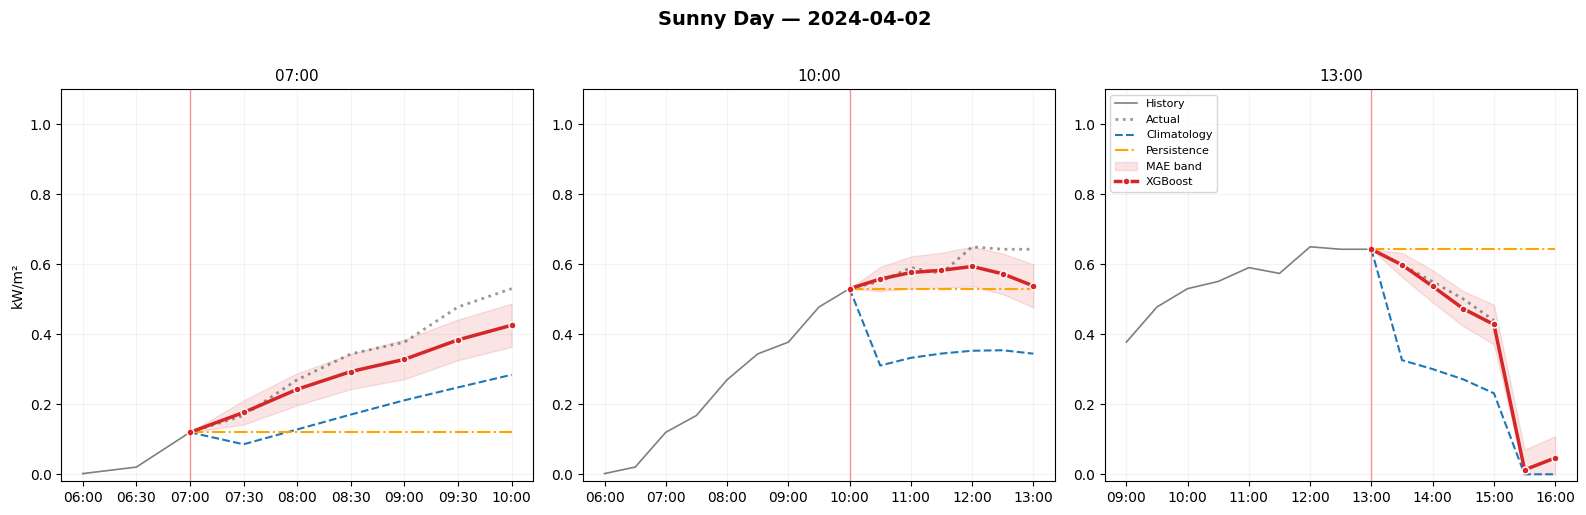

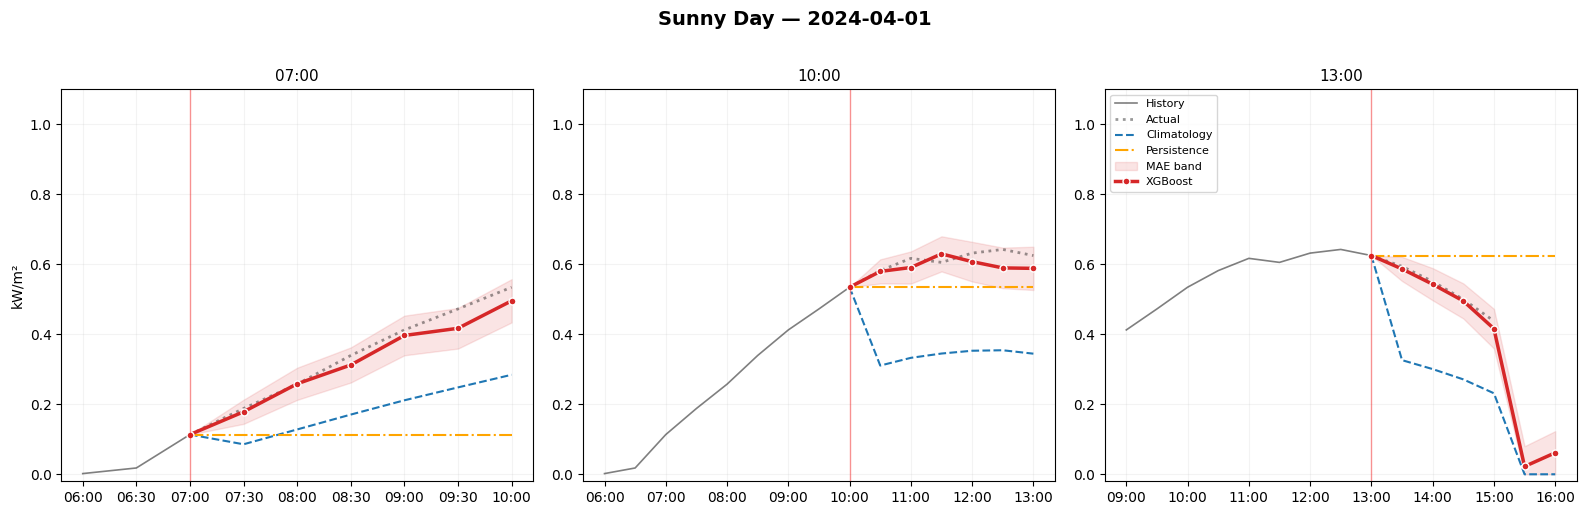

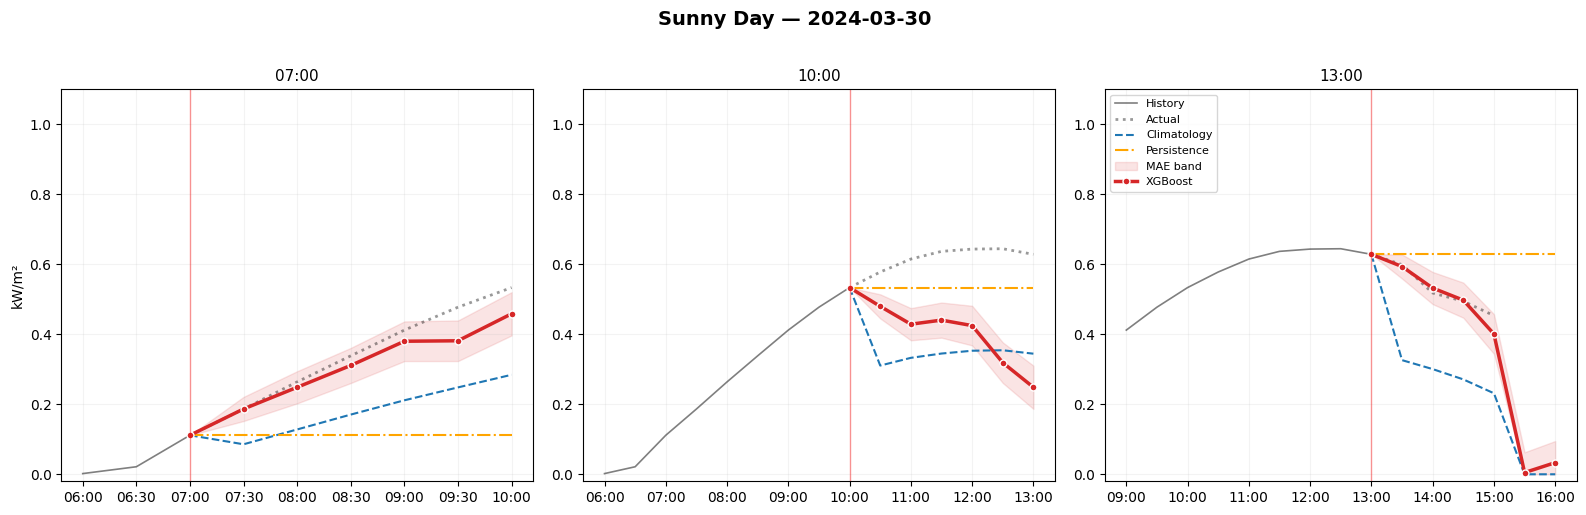

In [16]:
for d in sunny_dates:
    plot_day_comparison(str(d), 'Sunny Day')

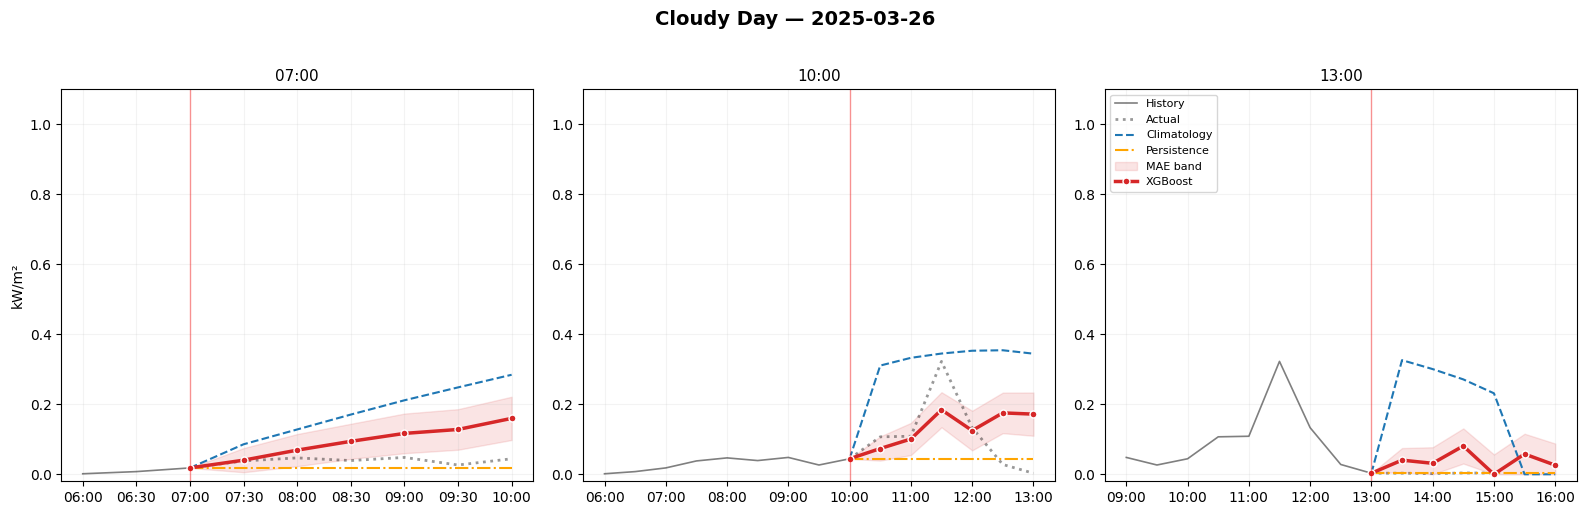

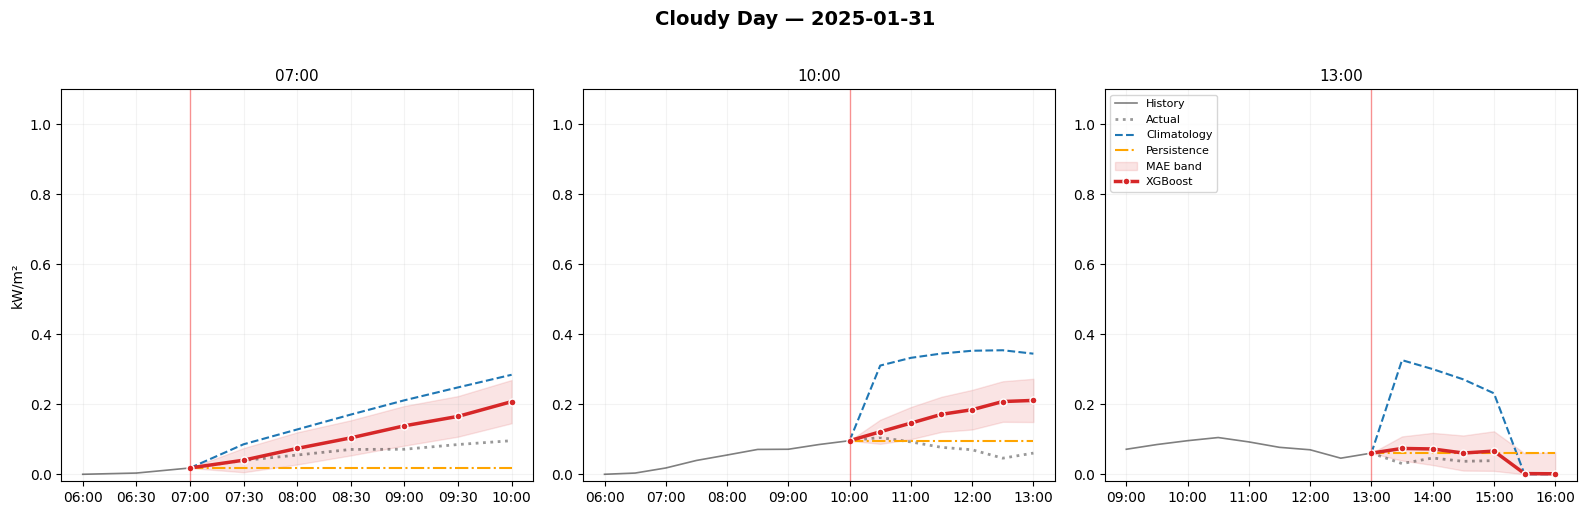

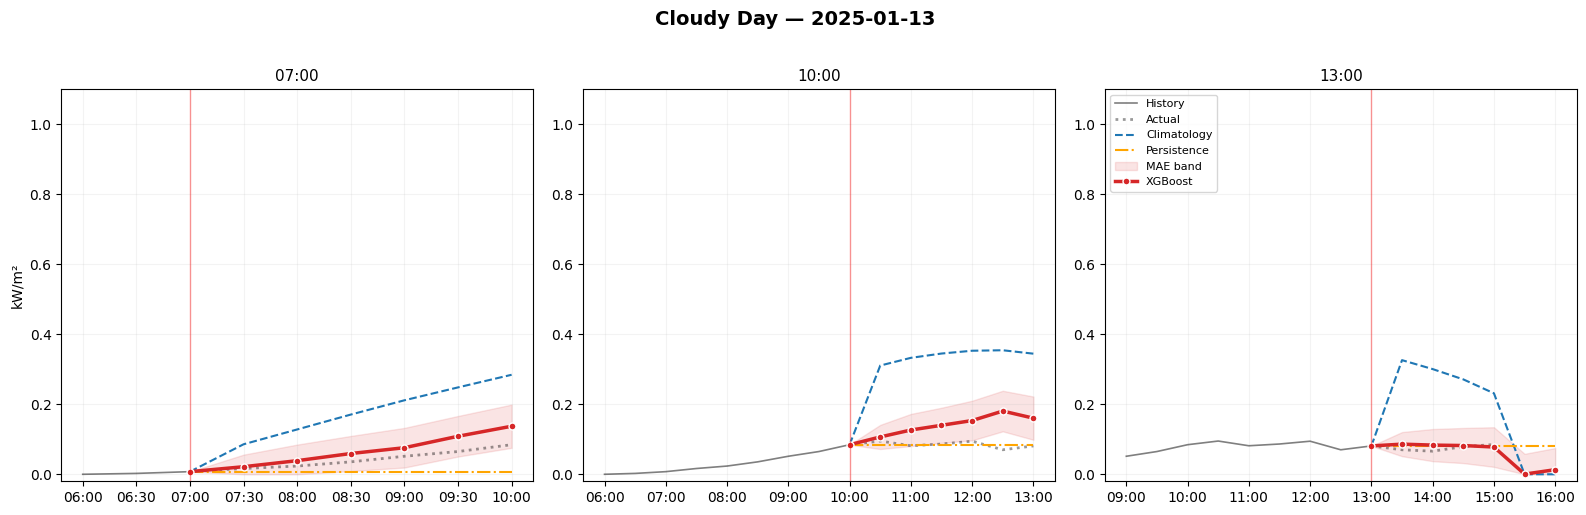

In [17]:
for d in cloudy_dates:
    plot_day_comparison(str(d), 'Cloudy Day')